In [21]:
import pandas as pd
import holidays
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import re
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt


In [ ]:
train_df = pd.read_csv("csv files/train_processed1.csv")
test_df = pd.read_csv("csv files/test_processed1.csv")
validation_df = pd.read_csv("csv files/validation_processed1.csv")

## Feature Engineering :

##### `Accident_Time` :

In [23]:
for dataset in [
    train_df,
    validation_df,
    test_df
]:
    dataset["Accident_Time"] = pd.to_datetime(
        dataset["Accident_Time"],
        errors="coerce"
    )

    us_holidays = holidays.UnitedStates(
        years=dataset["Accident_Time"].dt.year.dropna().unique()
    )

    is_public_holiday = dataset["Accident_Time"].dt.date.isin(us_holidays)

    # Monday=0, ..., Sunday=6
    is_weekend = dataset["Accident_Time"].dt.dayofweek >= 5

    dataset["is_holiday"] = (
        is_public_holiday | is_weekend
    ).astype("int8")

    dataset.drop(columns=["Accident_Time"], inplace=True)

removed `Accident_Time` column and replace it with `is_holiday` that represents weekend and jolidays in US

##### `Description` :

In [24]:
# Keep required columns
description_df = train_df[
    ["Description", "y"]
].dropna(subset=["y"]).copy()

# Fill missing descriptions
description_df["Description"] = (
    description_df["Description"]
    .fillna("")
    .astype(str)
)

# Set minimum word frequency
min_word_rows = max(
    5,
    int(len(description_df) * 0.0005)
)

# Create a binary word matrix
description_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    binary=True,
    min_df=min_word_rows,
    max_df=0.95,
    max_features=20000,
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)

description_matrix = description_vectorizer.fit_transform(
    description_df["Description"]
)

words = description_vectorizer.get_feature_names_out()
y_values = description_df["y"].astype(float).to_numpy()

# Count rows containing each word
word_row_counts = np.asarray(
    description_matrix.sum(axis=0)
).ravel()

# Sum y values for each word
word_y_sums = np.asarray(
    description_matrix.T @ y_values
).ravel()

# Calculate mean y for each word
word_mean_y = word_y_sums / word_row_counts

global_mean_y = y_values.mean()

word_target_stats = pd.DataFrame({
    "word": words,
    "row_count": word_row_counts,
    "row_percentage": (
        word_row_counts / len(description_df) * 100
    ),
    "mean_y": word_mean_y
})

# Measure difference from overall mean
word_target_stats["y_difference"] = (
    word_target_stats["mean_y"] - global_mean_y
)

# Balance frequency and target difference
word_target_stats["importance_score"] = (
    word_target_stats["y_difference"].abs()
    * np.log1p(word_target_stats["row_count"])
)

word_target_stats = word_target_stats.round({
    "row_percentage": 3,
    "mean_y": 3,
    "y_difference": 3,
    "importance_score": 3
})

# Most frequent words
top_frequent_words = (
    word_target_stats
    .sort_values(
        by="row_count",
        ascending=False
    )
    .head(50)
)

# Most target-sensitive words
top_sensitive_words = (
    word_target_stats
    .sort_values(
        by="importance_score",
        ascending=False
    )
    .head(50)
)

print(f"Overall mean y: {global_mean_y:.3f}")

display(top_frequent_words)
display(top_sensitive_words)

Overall mean y: 2.213


,word,row_count,row_percentage,mean_y,y_difference,importance_score
1,accident,51744,74.064,2.254,0.041,0.445
593,rd,21531,30.818,2.170,-0.043,0.430
235,exit,18360,26.280,2.427,0.214,2.102
487,near,15380,22.014,2.083,-0.130,1.254
76,blocked,14620,20.926,2.510,0.297,2.848
39,ave,13786,19.733,2.138,-0.075,0.710
678,st,13761,19.697,2.148,-0.064,0.614
358,incident,12872,18.424,2.057,-0.156,1.479
395,lane,12234,17.511,2.495,0.282,2.658
720,traffic,11972,17.136,2.031,-0.182,1.705


,word,row_count,row_percentage,mean_y,y_difference,importance_score
615,road,2790,3.993,2.991,0.778,6.174
155,closed,4862,6.959,2.797,0.584,4.961
236,exits,2510,3.593,2.698,0.485,3.795
396,lanes,2203,3.153,2.603,0.390,3.002
756,vicinity,207,0.296,2.773,0.560,2.990
475,motorists,259,0.371,2.749,0.536,2.982
669,southbound,5473,7.834,2.552,0.339,2.919
782,westbound,4223,6.045,2.556,0.343,2.865
76,blocked,14620,20.926,2.510,0.297,2.848
12,alternate,1242,1.778,2.605,0.392,2.792


In [25]:
# Prepare text
description_text = (
    train_df["Description"]
    .fillna("")
    .astype(str)
)

y_values = train_df["y"].astype(float)
global_mean_y = y_values.mean()

# Define text patterns
text_patterns = {
    "road closed": r"\broad\W+closed\b",
    "lane blocked": r"\blane\W+blocked\b",
    "lanes blocked": r"\blanes\W+blocked\b",
    "right hand shoulder": r"\bright\W+hand\W+shoulder\b",
    "left hand shoulder": r"\bleft\W+hand\W+shoulder\b",
    "shoulder blocked": r"\bshoulder\W+blocked\b",
    "re-opened": r"\bre[-\s]?opened\b",
    "road without closed after it": r"\broad\b(?!\W+closed\b)"
}

pattern_results = []

for pattern_name, regex_pattern in text_patterns.items():

    # Find matching rows
    pattern_mask = description_text.str.contains(
        regex_pattern,
        case=False,
        regex=True,
        na=False
    )

    row_count = pattern_mask.sum()

    if row_count > 0:
        mean_y = y_values.loc[pattern_mask].mean()
        y_difference = mean_y - global_mean_y

        importance_score = (
            abs(y_difference) * np.log1p(row_count)
        )
    else:
        mean_y = np.nan
        y_difference = np.nan
        importance_score = 0

    pattern_results.append({
        "text_pattern": pattern_name,
        "row_count": row_count,
        "row_percentage": (
            row_count / len(train_df) * 100
        ),
        "mean_y": mean_y,
        "y_difference": y_difference,
        "importance_score": importance_score
    })

selected_text_stats = pd.DataFrame(pattern_results)

selected_text_stats = selected_text_stats.round({
    "row_percentage": 3,
    "mean_y": 3,
    "y_difference": 3,
    "importance_score": 3
})

print(f"Overall mean y: {global_mean_y:.3f}")

display(selected_text_stats)

Overall mean y: 2.213


,text_pattern,row_count,row_percentage,mean_y,y_difference,importance_score
0,road closed,2165,3.099,3.205,0.992,7.621
1,lane blocked,10692,15.304,2.521,0.308,2.860
2,lanes blocked,1422,2.035,2.652,0.439,3.188
3,right hand shoulder,2186,3.129,2.518,0.305,2.345
4,left hand shoulder,712,1.019,2.650,0.437,2.874
5,shoulder blocked,3227,4.619,2.496,0.284,2.291
6,re-opened,37,0.053,3.000,0.787,2.863
7,road without closed after it,675,0.966,2.320,0.107,0.698


In [26]:
description_keywords = [
    "closed",
    "lanes blocked",
    "alternate",
    "alternative",
    "re-opened",
    "express",
    "queueing",
    "tractor",
    "trailer",
    "police"
]

# Match complete words and phrases
description_keyword_pattern = (
    r"(?<![a-z])(?:"
    + "|".join(
        re.escape(keyword)
        for keyword in description_keywords
    )
    + r")(?![a-z])"
)

for dataset in [
    train_df,
    validation_df,
    test_df
]:
    normalized_description = (
        dataset["Description"]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.replace(
            r"[‐-‒–—−]",
            "-",
            regex=True
        )
        .str.replace(
            r"\s+",
            " ",
            regex=True
        )
    )

    dataset["has_sensitive_word"] = (
        normalized_description
        .str.contains(
            description_keyword_pattern,
            regex=True,
            na=False
        )
        .astype("int8")
    )

    dataset.drop(
        columns=["Description"],
        inplace=True
    )

In [27]:
train_df["has_sensitive_word"].sum()

np.int64(6611)

Due to the limitation on the number of features, we could not use more complex text embedding methods to capture the semantic meaning of the `Description` column.

Instead, we analyzed the words appearing in the descriptions and calculated the average accident severity (`y`) for the records where each word appeared.

Words that:
- had a noticeable impact on the average severity,
- appeared frequently enough to make the conclusion reliable,
- and had a meaningful interpretation based on their context,

were identified as sensitive words related to accident severity.

Based on these selected words, we created a new binary feature:

`has_sensitive_word`

- `1`: if the description contains at least one sensitive word
- `0`: otherwise

This feature allows the model to use important information from the text descriptions while keeping the number of features limited.

##### `Street`, `City`, `County`, `State`, `Country` :

In [28]:
location_columns = [
    "Street",
    "City",
    "County",
    "State",
    "Country"
]

print("\n train_df unique values:")

display(
    train_df[location_columns]
    .nunique()
    .rename("unique_count")
    .to_frame()
)


 train_df unique values:


,unique_count
Street,22091
City,5616
County,1190
State,49
Country,1


In [29]:
for dataset in [
    train_df,
    validation_df,
    test_df
]:

    dataset.drop(
        columns=["Country"],
        inplace=True
    )

In [30]:
address_columns = [
    "Street",
    "City",
    "County",
    "State"
]

# Smoothing strengths
alpha_state = 10
alpha_county = 20
alpha_city = 30
alpha_street = 40

# Frequency weights
street_freq_weight = 0.7
city_freq_weight = 0.3


# Handle missing address values
for dataset in [
    train_df,
    validation_df,
    test_df
]:
    dataset[address_columns] = (
        dataset[address_columns]
        .fillna("__MISSING__")
        .astype(str)
    )


# Create hierarchical keys
def make_address_key(dataset, columns):
    return pd.Series(
        list(
            map(
                tuple,
                dataset[columns].to_numpy()
            )
        ),
        index=dataset.index
    )


# --------------------------------
# Address_Freq
# --------------------------------

train_street_key = make_address_key(
    train_df,
    ["State", "County", "City", "Street"]
)

train_city_key = make_address_key(
    train_df,
    ["State", "County", "City"]
)

street_freq_map = train_street_key.value_counts()
city_freq_map = train_city_key.value_counts()

train_size = len(train_df)
frequency_scale = np.log1p(train_size)


for dataset in [
    train_df,
    validation_df,
    test_df
]:
    street_key = make_address_key(
        dataset,
        ["State", "County", "City", "Street"]
    )

    city_key = make_address_key(
        dataset,
        ["State", "County", "City"]
    )

    street_frequency = (
        street_key
        .map(street_freq_map)
        .fillna(0)
    )

    city_frequency = (
        city_key
        .map(city_freq_map)
        .fillna(0)
    )

    # Log-normalize frequencies
    street_frequency_score = (
        np.log1p(street_frequency)
        / frequency_scale
    )

    city_frequency_score = (
        np.log1p(city_frequency)
        / frequency_scale
    )

    dataset["Address_Freq"] = (
        street_freq_weight
        * street_frequency_score
        +
        city_freq_weight
        * city_frequency_score
    ).astype("float32")


# --------------------------------
# Hierarchical target encoding
# --------------------------------

def fit_address_target_encoder(dataset):

    global_mean = dataset["y"].mean()

    # State level
    state_stats = (
        dataset
        .groupby("State", as_index=False)["y"]
        .agg(
            count="count",
            mean="mean"
        )
    )

    state_stats["encoded"] = (
        state_stats["count"] * state_stats["mean"]
        + alpha_state * global_mean
    ) / (
        state_stats["count"]
        + alpha_state
    )

    state_map = dict(
        zip(
            state_stats["State"],
            state_stats["encoded"]
        )
    )

    # County level
    county_stats = (
        dataset
        .groupby(
            ["State", "County"],
            as_index=False
        )["y"]
        .agg(
            count="count",
            mean="mean"
        )
    )

    county_stats["parent_mean"] = (
        county_stats["State"]
        .map(state_map)
        .fillna(global_mean)
    )

    county_stats["encoded"] = (
        county_stats["count"]
        * county_stats["mean"]
        +
        alpha_county
        * county_stats["parent_mean"]
    ) / (
        county_stats["count"]
        + alpha_county
    )

    county_keys = list(
        zip(
            county_stats["State"],
            county_stats["County"]
        )
    )

    county_map = dict(
        zip(
            county_keys,
            county_stats["encoded"]
        )
    )

    # City level
    city_stats = (
        dataset
        .groupby(
            ["State", "County", "City"],
            as_index=False
        )["y"]
        .agg(
            count="count",
            mean="mean"
        )
    )

    city_parent_keys = pd.Series(
        list(
            zip(
                city_stats["State"],
                city_stats["County"]
            )
        )
    )

    city_stats["parent_mean"] = (
        city_parent_keys
        .map(county_map)
        .fillna(global_mean)
        .to_numpy()
    )

    city_stats["encoded"] = (
        city_stats["count"]
        * city_stats["mean"]
        +
        alpha_city
        * city_stats["parent_mean"]
    ) / (
        city_stats["count"]
        + alpha_city
    )

    city_keys = list(
        zip(
            city_stats["State"],
            city_stats["County"],
            city_stats["City"]
        )
    )

    city_map = dict(
        zip(
            city_keys,
            city_stats["encoded"]
        )
    )

    # Street level
    street_stats = (
        dataset
        .groupby(
            [
                "State",
                "County",
                "City",
                "Street"
            ],
            as_index=False
        )["y"]
        .agg(
            count="count",
            mean="mean"
        )
    )

    street_parent_keys = pd.Series(
        list(
            zip(
                street_stats["State"],
                street_stats["County"],
                street_stats["City"]
            )
        )
    )

    street_stats["parent_mean"] = (
        street_parent_keys
        .map(city_map)
        .fillna(global_mean)
        .to_numpy()
    )

    street_stats["encoded"] = (
        street_stats["count"]
        * street_stats["mean"]
        +
        alpha_street
        * street_stats["parent_mean"]
    ) / (
        street_stats["count"]
        + alpha_street
    )

    street_keys = list(
        zip(
            street_stats["State"],
            street_stats["County"],
            street_stats["City"],
            street_stats["Street"]
        )
    )

    street_map = dict(
        zip(
            street_keys,
            street_stats["encoded"]
        )
    )

    return {
        "global_mean": global_mean,
        "state": state_map,
        "county": county_map,
        "city": city_map,
        "street": street_map
    }


def transform_address_mean(dataset, encoder):

    global_mean = encoder["global_mean"]

    # State fallback
    state_mean = (
        dataset["State"]
        .map(encoder["state"])
        .fillna(global_mean)
    )

    # County fallback
    county_key = make_address_key(
        dataset,
        ["State", "County"]
    )

    county_mean = (
        county_key
        .map(encoder["county"])
        .fillna(state_mean)
    )

    # City fallback
    city_key = make_address_key(
        dataset,
        ["State", "County", "City"]
    )

    city_mean = (
        city_key
        .map(encoder["city"])
        .fillna(county_mean)
    )

    # Street fallback
    street_key = make_address_key(
        dataset,
        ["State", "County", "City", "Street"]
    )

    street_mean = (
        street_key
        .map(encoder["street"])
        .fillna(city_mean)
    )

    return street_mean.astype("float32")


# --------------------------------
# OOF encoding for train
# --------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_address_mean = np.zeros(
    len(train_df),
    dtype=np.float32
)

for fit_index, fold_index in skf.split(
    train_df,
    train_df["y"]
):

    fold_train = train_df.iloc[fit_index]
    fold_data = train_df.iloc[fold_index]

    fold_encoder = fit_address_target_encoder(
        fold_train
    )

    train_address_mean[fold_index] = (
        transform_address_mean(
            fold_data,
            fold_encoder
        ).to_numpy()
    )

train_df["Address_Mean"] = train_address_mean


# --------------------------------
# Validation and test encoding
# --------------------------------

final_address_encoder = (
    fit_address_target_encoder(train_df)
)

validation_df["Address_Mean"] = (
    transform_address_mean(
        validation_df,
        final_address_encoder
    )
)

test_df["Address_Mean"] = (
    transform_address_mean(
        test_df,
        final_address_encoder
    )
)


# Remove original address columns
for dataset in [
    train_df,
    validation_df,
    test_df
]:
    dataset.drop(
        columns=address_columns,
        inplace=True
    )

In [31]:
test_df.head()


,Source,Additional_Lng,f6,f16,f17,f19,f20,f21,f22,f23,...,Location_Available,Wind_D_Calm,Wind_D_Variable,Wind_D_Sin,Wind_D_Cos,Record_Delay_Time,is_holiday,has_sensitive_word,Address_Freq,Address_Mean
0,2,0.389477,-0.687551,1.162012,0.484170,-0.617912,0.176585,0,0,0,...,0,0,0,-1.546259,0.114939,0.357251,0,0,0.258114,2.483689
1,1,0.201932,0.677977,1.250132,0.484170,-1.599322,-0.642293,0,0,0,...,1,1,0,0.055602,0.114939,-0.011089,0,0,0.346102,2.087410
2,1,-1.356429,0.216356,-0.115718,0.123766,0.534177,-0.642293,0,0,0,...,1,0,0,-1.546259,0.114939,0.311310,0,0,0.324892,2.300897
3,1,1.046573,-0.660965,-0.055187,0.264889,-0.260364,0.700926,0,0,0,...,1,0,0,-0.214239,-0.078410,-0.003354,0,1,0.099427,2.319774
4,1,0.756926,0.607888,0.941714,0.579014,2.239867,1.449837,0,0,0,...,1,0,0,-1.077085,-1.057407,0.217395,0,0,0.117135,2.295063


Because `Street`, `City`, `County`, and `State` contain a very large number of unique values, using One-Hot Encoding would create too many features and exceed the feature limitation of the project.

Instead, we compressed these four location features into two numerical features: `Address_Freq` and `Address_Mean`.

##### `Address_Freq`

`Address_Freq` represents how common the accident location is based mainly on the frequency of the street and city.

To prevent very frequent locations from dominating the feature, the frequencies were first log-scaled:

$$
StreetScore =
\frac{\log(1 + StreetFreq)}
{\log(1 + N)}
$$

$$
CityScore =
\frac{\log(1 + CityFreq)}
{\log(1 + N)}
$$

Then they were combined with a higher weight for the street because it represents a more specific location:

$$
Address\_Freq =
0.7 \times StreetScore +
0.3 \times CityScore
$$

##### `Address_Mean`

For accident severity, we used **Hierarchical Smoothed Target Encoding** instead of directly using the raw mean of each street.

The hierarchy was:

`Street → City → County → State → Global Mean`

At each level, the local mean was smoothed toward the more general level depending on the number of available samples. Therefore, locations with many observations rely more on their own severity mean, while locations with limited data rely more on broader and more reliable geographical information.

For example:

$$
StateMean =
\frac{
n_{state} \times RawStateMean +
\alpha_{state} \times GlobalMean
}{
n_{state} + \alpha_{state}
}
$$

and the same idea was applied progressively to `County`, `City`, and finally `Street`.

The final smoothed street value was used as `Address_Mean`.

To prevent target leakage, `Address_Mean` for the training set was generated using **Out-of-Fold Target Encoding**, so each training row was encoded without using its own target value. All statistics used for validation and test data were calculated only from the training set.

After creating `Address_Freq` and `Address_Mean`, the original `Street`, `City`, `County`, and `State` columns were removed.

In [32]:
address_features = [
    "Address_Freq",
    "Address_Mean"
]

# Fit only on train data
address_power_transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=True
)

train_df[address_features] = (
    address_power_transformer.fit_transform(
        train_df[address_features]
    )
)

# Apply the same transformation
validation_df[address_features] = (
    address_power_transformer.transform(
        validation_df[address_features]
    )
)

test_df[address_features] = (
    address_power_transformer.transform(
        test_df[address_features]
    )
)

Finally, the newly created `Address_Freq` and `Address_Mean` features were transformed to make their distributions closer to normal, making them more suitable for the modeling stage.

#### temporary part (just to create a pickle file for final.ipynb file to run)

In [ ]:
# # Save train-based feature engineering parameters for future inference.

# import pickle


# def convert_encoder_to_python(encoder):
#     return {
#         "global_mean": float(encoder["global_mean"]),

#         "state": {
#             key: float(value)
#             for key, value in encoder["state"].items()
#         },

#         "county": {
#             key: float(value)
#             for key, value in encoder["county"].items()
#         },

#         "city": {
#             key: float(value)
#             for key, value in encoder["city"].items()
#         },

#         "street": {
#             key: float(value)
#             for key, value in encoder["street"].items()
#         }
#     }


# feature_engineering_params = {

#     "address_frequency": {
#         "street_freq_map": {
#             key: int(value)
#             for key, value in street_freq_map.items()
#         },

#         "city_freq_map": {
#             key: int(value)
#             for key, value in city_freq_map.items()
#         },

#         "frequency_scale": float(frequency_scale),

#         "street_weight": float(street_freq_weight),
#         "city_weight": float(city_freq_weight)
#     },

#     "address_target_encoder":
#         convert_encoder_to_python(
#             final_address_encoder
#         ),

#     "address_power_transformer":
#         address_power_transformer
# }


# with open(
#     "to_run_for_new_data/03_feature_engineering_params.pkl",
#     "wb"
# ) as file:

#     pickle.dump(
#         feature_engineering_params,
#         file
#     )


# print(
#     "Feature engineering parameters "
#     "saved successfully."
# )

Feature engineering parameters saved successfully.


## Feature Selection :

In [13]:
feature_stats = []

for column in train_df.columns:
    if column == "y":
        continue

    value_counts = train_df[column].value_counts(
        dropna=False
    )

    unique_count = train_df[column].nunique(
        dropna=False
    )

    most_common_value = value_counts.index[0]
    most_common_count = value_counts.iloc[0]

    most_common_percentage = (
        most_common_count / len(train_df) * 100
    )

    feature_stats.append({
        "Feature": column,
        "Unique_Count": unique_count,
        "Most_Common_Value": most_common_value,
        "Most_Common_Count": most_common_count,
        "Most_Common_Percentage": most_common_percentage
    })

feature_stats_df = pd.DataFrame(feature_stats)

# Sort by dominance
feature_stats_df = (
    feature_stats_df
    .sort_values(
        "Most_Common_Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_stats_df["Most_Common_Percentage"] = (
    feature_stats_df["Most_Common_Percentage"]
    .round(2)
)

display(feature_stats_df)

,Feature,Unique_Count,Most_Common_Value,Most_Common_Count,Most_Common_Percentage
0,f31,1,0.000000,69864,100.00
1,f26,2,0.000000,69859,99.99
2,f22,2,0.000000,69825,99.94
3,f29,2,0.000000,69795,99.90
4,f23,2,0.000000,69538,99.53
5,f25,2,0.000000,69218,99.08
6,f21,2,0.000000,68988,98.75
7,f27,2,0.000000,68067,97.43
8,f28,2,0.000000,67960,97.27
9,Wind_D_Variable,2,0.000000,66607,95.34


In [14]:
features_to_drop = [
    "f23",
    "f29",
    "f22",
    "f26",
    "f31"
]

for dataset in [
    train_df,
    validation_df,
    test_df
]:
    dataset.drop(
        columns=features_to_drop,
        inplace=True
    )

In [15]:
# Select numeric features
numeric_features = (
    train_df
    .drop(columns=["y"], errors="ignore")
    .select_dtypes(include=np.number)
    .columns
)

# Calculate correlation matrix
correlation_matrix = (
    train_df[numeric_features]
    .corr(method="pearson")
)

correlation_pairs = []

for i in range(len(numeric_features)):
    for j in range(i + 1, len(numeric_features)):
        feature_1 = numeric_features[i]
        feature_2 = numeric_features[j]

        correlation = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        correlation_pairs.append({
            "Feature_1": feature_1,
            "Feature_2": feature_2,
            "Correlation": correlation,
            "Absolute_Correlation": abs(correlation)
        })

correlation_pairs_df = pd.DataFrame(
    correlation_pairs
)

# Sort from highest correlation
correlation_pairs_df = (
    correlation_pairs_df
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

correlation_pairs_df[
    ["Correlation", "Absolute_Correlation"]
] = correlation_pairs_df[
    ["Correlation", "Absolute_Correlation"]
].round(4)

display(correlation_pairs_df)

,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,Source,Location_Available,-0.9773,0.9773
1,D2,D3,0.8758,0.8758
2,D1,D2,0.7782,0.7782
3,D1,D3,0.6813,0.6813
4,f19,Wind_D_Calm,-0.5375,0.5375
...,...,...,...,...
320,f21,D2,0.0004,0.0004
321,f28,Wind_D_Sin,0.0002,0.0002
322,f19,f28,0.0002,0.0002
323,f20,has_sensitive_word,0.0002,0.0002


Counts:


Location_Available,0,1
Source,,
1,0,39140
2,29842,0
3,882,0


Percentages:


Location_Available,0,1
Source,,
1,0.0,100.0
2,100.0,0.0
3,100.0,0.0


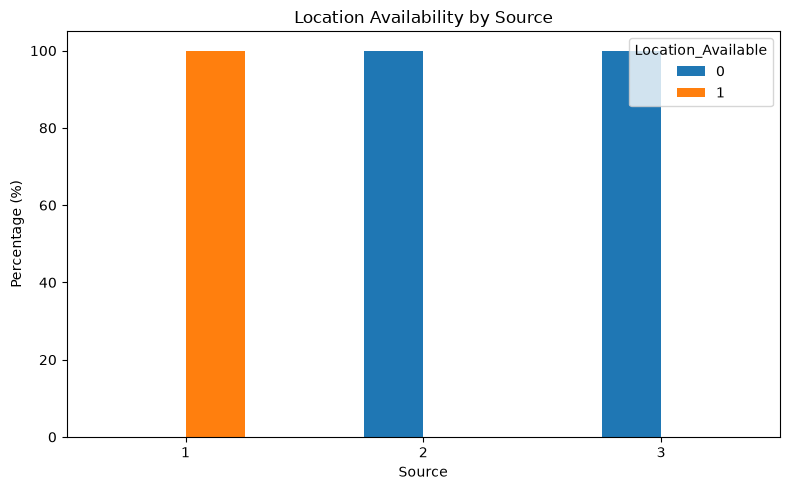

In [16]:
# Count each combination
source_location_count = pd.crosstab(
    train_df["Source"],
    train_df["Location_Available"]
)

# Calculate row percentages
source_location_percentage = pd.crosstab(
    train_df["Source"],
    train_df["Location_Available"],
    normalize="index"
) * 100

print("Counts:")
display(source_location_count)

print("Percentages:")
display(
    source_location_percentage.round(2)
)

# Plot percentages
source_location_percentage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Location Availability by Source"
)
plt.xlabel("Source")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Location_Available"
)
plt.tight_layout()
plt.show()

In [17]:
for dataset in [
    train_df,
    validation_df,
    test_df
]:
    dataset.drop(
        columns=["Location_Available"],
        inplace=True
    )

In [18]:
train_df.head()

,Source,Additional_Lng,f6,f16,f17,f19,f20,f21,f24,f25,...,y,Wind_D_Calm,Wind_D_Variable,Wind_D_Sin,Wind_D_Cos,Record_Delay_Time,is_holiday,has_sensitive_word,Address_Freq,Address_Mean
0,2,-1.006353,-0.687551,-2.406821,-1.507539,1.387576,-0.642293,0,0,0,...,3,0,0,1.535528,0.749407,0.268215,0,0,0.774040,-0.454827
1,1,1.266035,0.404871,0.457058,0.522108,-0.319223,-0.642293,0,1,0,...,2,0,1,0.055602,0.114939,0.279598,0,1,-0.873380,-0.592416
2,1,-1.541957,-0.687551,-1.525627,0.332421,-0.959272,0.078081,0,0,0,...,2,0,0,-1.077085,1.287284,-0.396098,0,0,-0.895220,-1.060075
3,1,-1.704913,-0.465200,0.183969,-0.745888,-0.069884,0.754176,0,0,0,...,2,0,0,-0.026764,0.012387,-0.003354,1,0,-1.198836,-1.221902
4,1,0.828390,-0.286352,-0.159778,0.844575,-0.319223,-0.642293,0,0,0,...,2,0,0,-0.557404,1.646681,0.592647,0,0,1.207867,-1.220476


##### Removing Low-Information and Redundant Features

We checked the value distribution of all features and removed columns where more than `99.5%` of the rows contained the same value, since such features provide almost no useful information for the model.

We also examined correlations between features. Since `Location_Available` and `Source` were highly correlated, we removed `Location_Available` to reduce redundant information and kept `Source`.

In [ ]:
train_df.to_csv(
    "csv files/train_final.csv",
    index=False,
    encoding="utf-8-sig"
)
test_df.to_csv(
    "csv files/test_final.csv",
    index=False,
    encoding="utf-8-sig"
)
validation_df.to_csv(
    "csv files/validation_final.csv",
    index=False,
    encoding="utf-8-sig"
)